In [17]:
!pip install tensorflow opencv-python pillow matplotlib scikit-learn streamlit

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [19]:
print("Current folder files:")
print(os.listdir())

Current folder files:
['app.py', 'archive.zip', 'dataset', 'requirements.txt', 'training.ipynb']


In [20]:
zip_path = "archive.zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

Dataset extracted successfully


In [21]:
for root, dirs, files in os.walk("dataset"):
    image_files = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if image_files:
        print("Folder:", root)
        print("Example files:", image_files[:3])
        print("-" * 50)

Folder: dataset\Bicycle
Example files: ['2015_00001.png', '2015_00002.png', '2015_00003.png']
--------------------------------------------------
Folder: dataset\Boat
Example files: ['2015_00653.jpg', '2015_00654.jpg', '2015_00655.jpg']
--------------------------------------------------
Folder: dataset\Bottle
Example files: ['2015_01332.jpg', '2015_01333.jpg', '2015_01334.jpg']
--------------------------------------------------
Folder: dataset\Bus
Example files: ['2015_01879.jpg', '2015_01880.png', '2015_01881.png']
--------------------------------------------------
Folder: dataset\Car
Example files: ['2015_02406.jpg', '2015_02407.jpg', '2015_02408.jpg']
--------------------------------------------------
Folder: dataset\Cat
Example files: ['2015_03042.jpg', '2015_03043.jpg', '2015_03044.jpg']
--------------------------------------------------
Folder: dataset\Chair
Example files: ['2015_03777.png', '2015_03778.jpg', '2015_03779.jpg']
--------------------------------------------------
Fol

In [22]:
target_classes = ["Car", "Bus", "Bicycle", "Motorbike"]

class_to_label = {
    "Car": 0,
    "Bus": 1,
    "Bicycle": 2,
    "Motorbike": 3
}

print("Using classes:", target_classes)

Using classes: ['Car', 'Bus', 'Bicycle', 'Motorbike']


In [23]:
img_size = 128

data = []
labels = []
class_names = []

for root, dirs, files in os.walk("dataset"):
    folder_name = os.path.basename(root)
    if folder_name in target_classes:
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                path = os.path.join(root, file)
                img = cv2.imread(path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (img_size, img_size))
                    data.append(img)
                    labels.append(class_to_label[folder_name])
                    class_names.append(folder_name)

X = np.array(data, dtype="float32") / 255.0
y = np.array(labels)

print("Total images loaded:", len(X))
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y))

Total images loaded: 2319
X shape: (2319, 128, 128, 3)
y shape: (2319,)
Unique labels: [0 1 2 3]


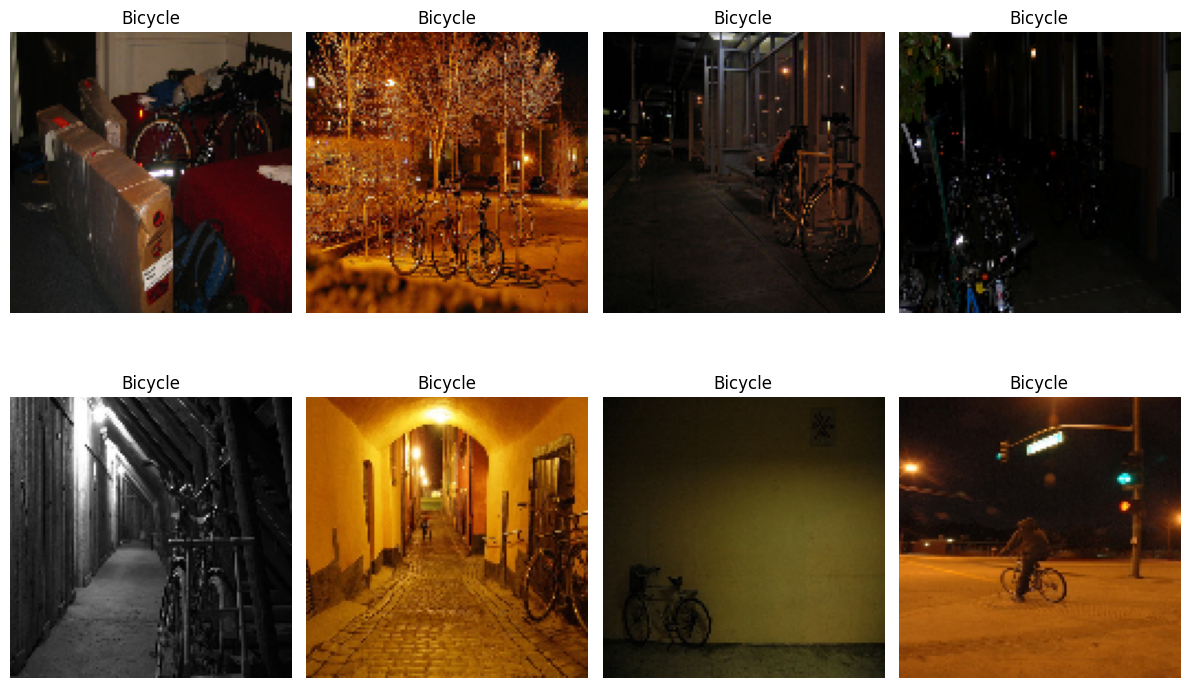

In [24]:
plt.figure(figsize=(12, 8))

for i in range(min(8, len(X))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X[i])
    plt.title(class_names[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1855
Testing samples: 464


In [26]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\Khushi Wadhawan\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=16
)

Epoch 1/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.3261 - loss: 1.3773 - val_accuracy: 0.3017 - val_loss: 1.3534
Epoch 2/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.4049 - loss: 1.2976 - val_accuracy: 0.3901 - val_loss: 1.3082
Epoch 3/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.4642 - loss: 1.2144 - val_accuracy: 0.3944 - val_loss: 1.3445
Epoch 4/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.5580 - loss: 1.0813 - val_accuracy: 0.4289 - val_loss: 1.3389
Epoch 5/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - accuracy: 0.6350 - loss: 0.8921 - val_accuracy: 0.4181 - val_loss: 1.5176
Epoch 6/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.7353 - loss: 0.6921 - val_accuracy: 0.4310 - val_loss: 1.6124
Epoch 7/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.8270 - loss: 0.4608 - val_accuracy: 0.3987 - val_loss: 2.1149
Epoch 8/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.8900 - loss: 0.3111 - val_acc

In [28]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4159 - loss: 3.1488
Test Loss: 3.1488287448883057
Test Accuracy: 0.4159482717514038


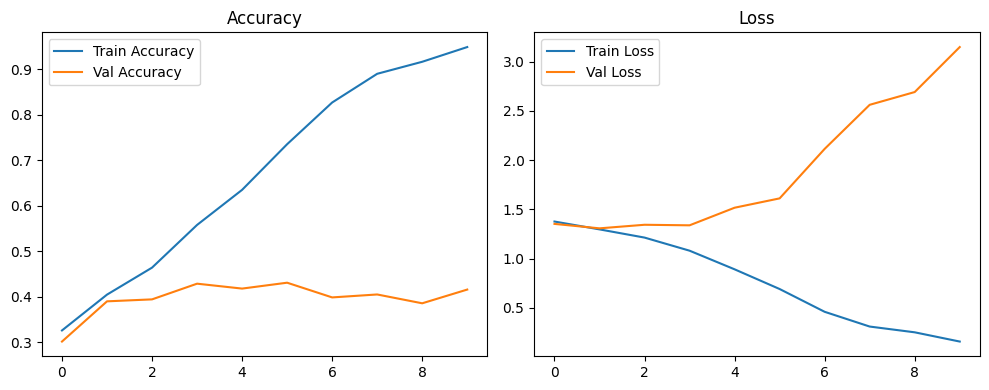

In [29]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
model.save("unsafe_zone_cnn_model.h5")
print("Model saved successfully")

Model saved successfully


In [31]:
print(os.listdir())

['app.py', 'archive.zip', 'dataset', 'requirements.txt', 'training.ipynb', 'unsafe_zone_cnn_model.h5']
